## We are interested in predicting whether an individual will default on his or her credit card payment, on the basis of annual income and monthly credit card balance.

In [141]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm

from sklearn import metrics
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,KFold,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [142]:
df=pd.read_csv(r'./data/credit.csv')
df.head()

,Unnamed: 0,default,student,balance,income
0,1,No,No,729.526495,44361.625074
1,2,No,Yes,817.180407,12106.134700
2,3,No,No,1073.549164,31767.138947
3,4,No,No,529.250605,35704.493935
4,5,No,No,785.655883,38463.495879


In [143]:
df.drop(["Unnamed: 0"],axis=1,inplace=True)

In [144]:
# replace yes and no with 1 and 0
df['default'] = df['default'].map({'Yes': 1, 'No': 0})
df['student'] = df['student'].map({'Yes': 1, 'No': 0})
df.head()

,default,student,balance,income
0,0,0,729.526495,44361.625074
1,0,1,817.180407,12106.134700
2,0,0,1073.549164,31767.138947
3,0,0,529.250605,35704.493935
4,0,0,785.655883,38463.495879


## Checking the shape

In [145]:
df.shape

(10000, 4)

## Checking the Info

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  int64  
 1   student  10000 non-null  int64  
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 312.6 KB


## FROM SLIDES

Calculate: 
![alt text](image.png)

In [147]:
len(df[df['student'] == 'Yes'])

0

In [148]:
# calculate the probability of A | B = P(A and B) / P(B) where A is default and B is student
# values are stored as 1 and 0
# do first just probability of default AND student
prob_default_and_student = len(df[(df['default'] == 1) & (df['student'] == 1)]) / len(df)
print(f"P(default and student): {prob_default_and_student:.4f}")

# now calculate the probability of student
prob_student = len(df[df['student'] == 1]) / len(df)
print(f"P(student): {prob_student:.4f}")

# now calculate the probability of default given student
prob_default_given_student = prob_default_and_student / prob_student
print(f"P(default | student): {prob_default_given_student:.4f}")

P(default and student): 0.0127
P(student): 0.2944
P(default | student): 0.0431


In [149]:
# calculate the probability of default AND not student
prob_default_and_not_student = len(df[(df['default'] == 1) & (df['student'] == 0)]) / len(df)
print(f"P(default and not student): {prob_default_and_not_student:.4f}")

# calculate the probability of not student
prob_not_student = len(df[df['student'] == 0]) / len(df)
print(f"P(not student): {prob_not_student:.4f}")

# calculate the probability of default given not student
prob_default_given_not_student = prob_default_and_not_student / prob_not_student
print(f"P(default | not student): {prob_default_given_not_student:.4f}")

P(default and not student): 0.0206
P(not student): 0.7056
P(default | not student): 0.0292


## Describing the data/Checking the summary statistics

In [150]:
df.describe()

,default,student,balance,income
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.033300,0.294400,835.374886,33516.981876
std,0.179428,0.455795,483.714985,13336.639563
min,0.000000,0.000000,0.000000,771.967729
25%,0.000000,0.000000,481.731105,21340.462903
50%,0.000000,0.000000,823.636973,34552.644802
75%,0.000000,1.000000,1166.308386,43807.729272
max,1.000000,1.000000,2654.322576,73554.233495


# Univariate and Bivariate Anlaysis

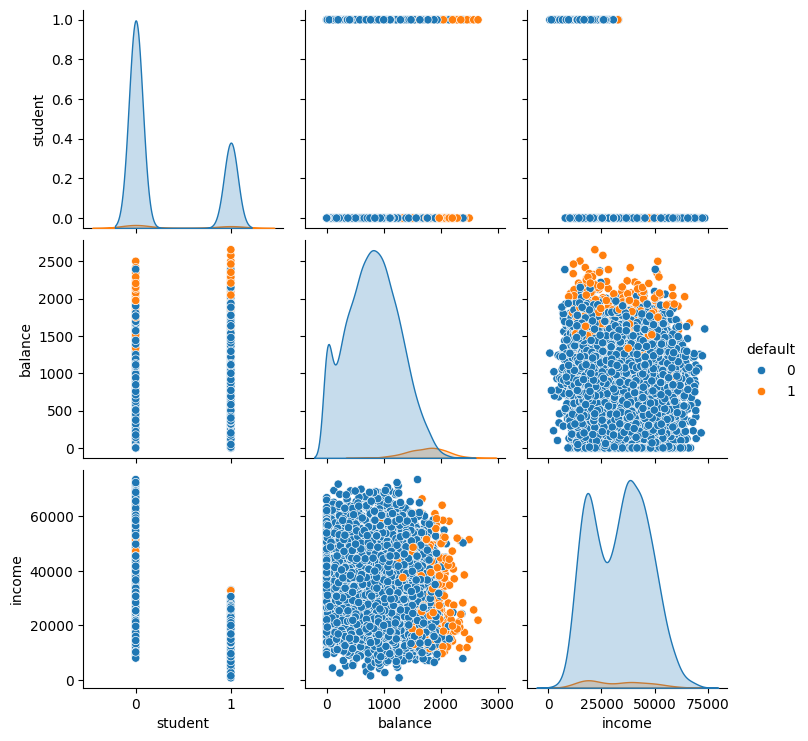

In [151]:
# seaborn pairplot of the data
sns.pairplot(df, hue='default')
plt.show()


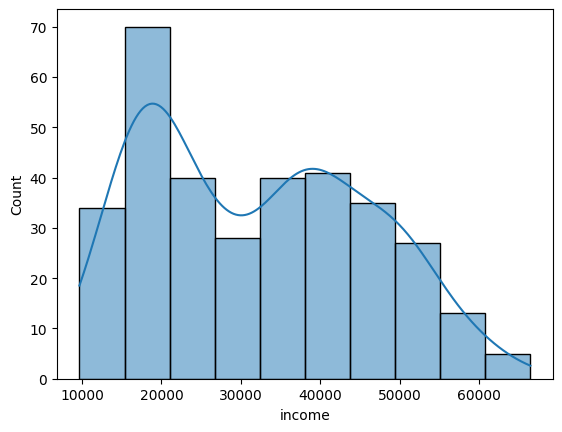

In [173]:
# sns historam of income filter the data by default = 1
sns.histplot(data=df[df['default'] == 1], x='income', kde=True)
plt.show()  


## Income Vs Balance

In [152]:
px.scatter(data_frame=df,x='balance',y='income',color='default')

The annual incomes and monthly
credit card balances of a number of individuals. The individuals who defaulted on
their credit card payments are shown in red, and those who did not are shown
in blue.

## Boxplots

In [153]:
px.box(df,x='default',y='balance',color_discrete_sequence=["red"])

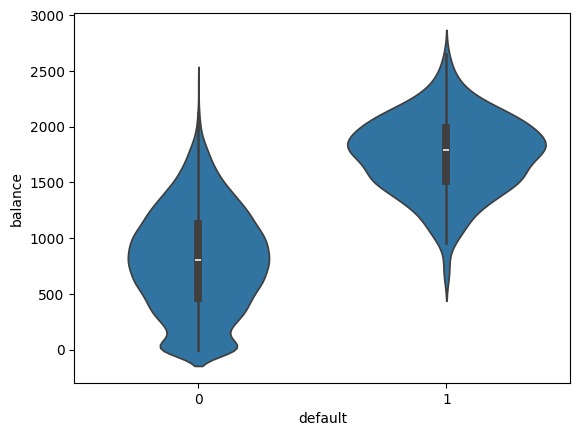

In [154]:
# violin plot of balance by default
sns.violinplot(x='default', y='balance', data=df)
plt.show()


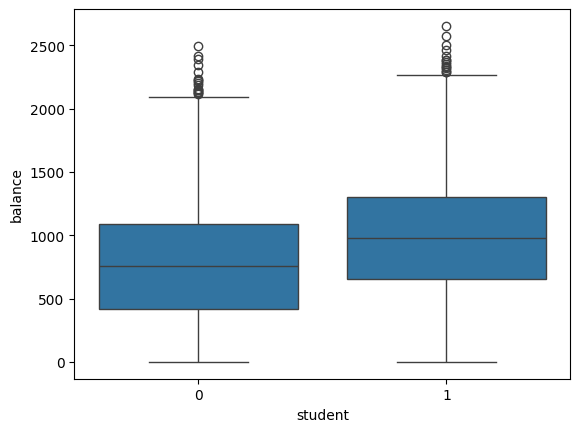

In [155]:
# seaborn boxplot of balance by student
sns.boxplot(x='student', y='balance', data=df)
plt.show()

The fact that students on the whole tend to have higher credit card
balances means that overall, students tend to default at a higher rate than
non-students. This is an important distinction for a credit card company
that is trying to determine to whom they should offer credit. 

## LOGISTIC REGRESSION

Similar to how we structured our linear regression models, we will delcare the X, add a constant, and fit the model.

Remember we are using ALL the date for both training and testing so it's likely overfit but it's fine for now

In [174]:
X = sm.add_constant(df['balance'])
y = df['default']

logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.079823
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Wed, 25 Mar 2026   Pseudo R-squ.:                  0.4534
Time:                        12:36:57   Log-Likelihood:                -798.23
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                6.233e-290
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.6513      0.361    -29.491      0.000     -11.359      -9.943
balance        0.0055      0

### How to Read the Coefficient Output

- `coef`: estimated effect of each predictor on the **log-odds** of default
- `P>|z|`: p-value used to judge statistical significance
- `[0.025, 0.975]`: 95% confidence interval for the coefficient

A positive coefficient increases the predicted log-odds of default, while a negative coefficient decreases them.

In [163]:
X = sm.add_constant(df['student'])
y = df['default']

logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.145434
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Wed, 25 Mar 2026   Pseudo R-squ.:                0.004097
Time:                        12:30:21   Log-Likelihood:                -1454.3
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                 0.0005416
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.5041      0.071    -49.554      0.000      -3.643      -3.366
student        0.4049      0.

### Interpreting the Logistic Regression Output

The logistic regression output shows that the coefficient for `income` is negative. In this model, that means higher income is associated with lower log-odds of credit card default.

Because this is a logistic model, the coefficient is describing the direction of the relationship on the log-odds scale rather than a direct change in probability. The sign is the main takeaway here: as income increases, the model predicts a lower likelihood of default, holding the rest of the model fixed.

## Confusion Matrix

In practice, a binary classifier such as this one can make two types of
errors: it can incorrectly assign an individual who defaults to the no default
category, or it can incorrectly assign an individual who does not default to
the default category. It is often of interest to determine which of these two
types of errors are being made. A confusion matrix, shown for the Default confusion
data is a convenient way to display this information.

In [164]:
# generate the confusion matrix on the model for the entire dataset
y_pred = logit_model.predict(X) >= 0.03
conf_matrix = metrics.confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[6850 2817]
 [ 206  127]]


In [159]:
# calculate the accuracy, precision, recall, and F1-score
accuracy = metrics.accuracy_score(y, y_pred)
precision = metrics.precision_score(y, y_pred)
recall = metrics.recall_score(y, y_pred)
f1_score = metrics.f1_score(y, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")


Accuracy: 0.2208
Precision: 0.0334
Recall: 0.8018
F1 Score: 0.0641


In [165]:
# add more variables to the model
X = sm.add_constant(df[['income', 'balance', 'student']])
y = df['default']
logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())
    

Optimization terminated successfully.
         Current function value: 0.078577
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9996
Method:                           MLE   Df Model:                            3
Date:                Wed, 25 Mar 2026   Pseudo R-squ.:                  0.4619
Time:                        12:31:12   Log-Likelihood:                -785.77
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                3.257e-292
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.8690      0.492    -22.079      0.000     -11.834      -9.904
income      3.033e-06    8.2

### Summary of the Logistic Regression Output

This updated logistic regression model uses `income`, `balance`, and `student` to predict default. The overall model is statistically significant, which means the predictors collectively help explain default risk.

The key result is that **income is not statistically significant** in this model (`p = 0.712`). After accounting for the other variables, there is not enough evidence that income has a meaningful relationship with default.

By contrast, **balance is highly significant and positive**, so higher credit card balances are associated with a higher likelihood of default. The **student** coefficient is negative and statistically significant in this model, which suggests that once balance and income are held constant, students have lower log-odds of default than non-students.

So the main takeaway is that **balance is doing most of the predictive work here, while income does not appear to add useful information once the other variables are included**.

In [168]:
# generate the confusion matrix on the model for the entire dataset
y_pred = logit_model.predict(X) >= 0.5
conf_matrix = metrics.confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
# calculate the accuracy, precision, recall, and F1-score
accuracy = metrics.accuracy_score(y, y_pred)
precision = metrics.precision_score(y, y_pred)
recall = metrics.recall_score(y, y_pred)
f1_score = metrics.f1_score(y, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")



Confusion Matrix:
[[9627   40]
 [ 228  105]]
Accuracy: 0.9732
Precision: 0.7241
Recall: 0.3153
F1 Score: 0.4393


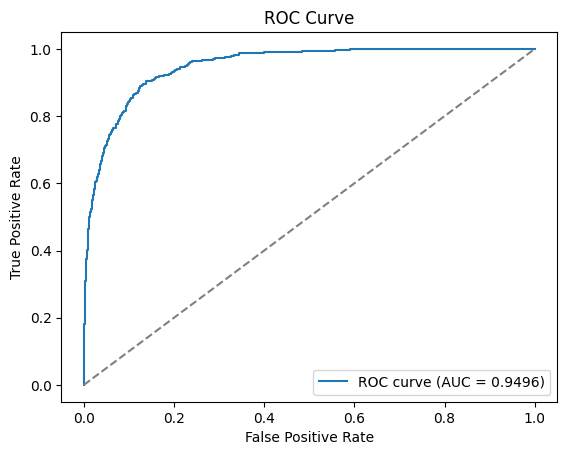

In [169]:
# generate the ROC curve and calculate the AUC
fpr, tpr, thresholds = metrics.roc_curve(y, logit_model.predict(X))
auc = metrics.roc_auc_score(y, logit_model.predict(X))

#graph the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], '--', color='gray')  # add a diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()




In [171]:
# create the model with a threshold of .2 and generate the confusion matrix on the model for the entire dataset
threshold = 0.6
y_pred = logit_model.predict(X) >= threshold
conf_matrix = metrics.confusion_matrix(y, y_pred)
accuracy = metrics.accuracy_score(y, y_pred)
precision = metrics.precision_score(y, y_pred)
recall = metrics.recall_score(y, y_pred)
f1_score = metrics.f1_score(y, y_pred)
print(f"Threshold: {threshold:.2f}")
print("Confusion Matrix:")
print(conf_matrix)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")


Threshold: 0.60
Confusion Matrix:
[[9644   23]
 [ 252   81]]
Accuracy: 0.9725
Precision: 0.7788
Recall: 0.2432
F1 Score: 0.3707
